In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("sales_data.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df['Date'] 

0       2022-01-01
1       2022-01-01
2       2022-01-01
3       2022-01-01
4       2022-01-01
           ...    
75995   2024-01-30
75996   2024-01-30
75997   2024-01-30
75998   2024-01-30
75999   2024-01-30
Name: Date, Length: 76000, dtype: datetime64[us]

In [8]:
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['day_of_week'] = df['Date'].dt.day_name()

In [11]:
df['month'].head()

0    1
1    1
2    1
3    1
4    1
Name: month, dtype: int32

In [12]:
df['year'].head()

0    2022
1    2022
2    2022
3    2022
4    2022
Name: year, dtype: int32

In [13]:
df['day_of_week'].head()

0    Saturday
1    Saturday
2    Saturday
3    Saturday
4    Saturday
Name: day_of_week, dtype: str

Sales Trend

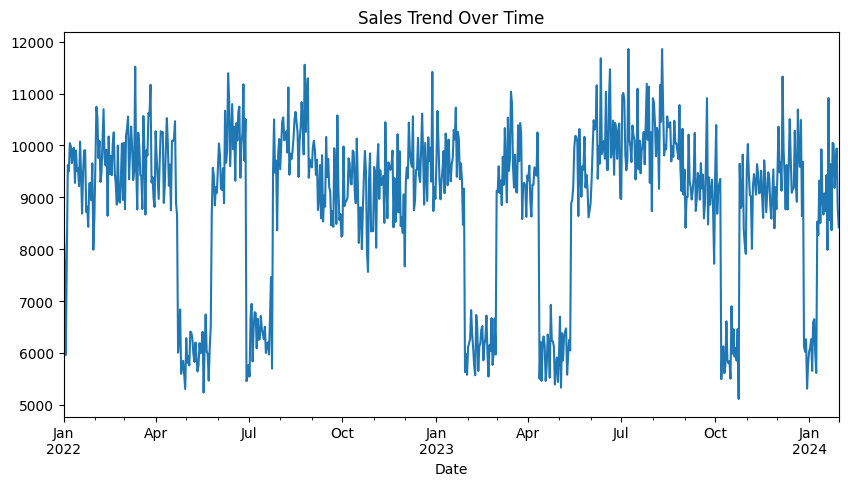

In [18]:
plt.figure(figsize=(10,5))
df.groupby('Date')['Units Sold'].sum().plot()
plt.title("Sales Trend Over Time")
plt.show()

In [21]:
top_products = df.groupby('Product ID')['Units Sold'].sum().sort_values(ascending=False).head(10)
print(top_products) # top product 

Product ID
P0007    379709
P0004    377627
P0009    376771
P0013    376717
P0002    359355
P0010    357299
P0001    356814
P0005    351765
P0006    344589
P0003    341531
Name: Units Sold, dtype: int64


In [27]:
print(df.columns)

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'month', 'year', 'day_of_week'],
      dtype='str')


<Axes: xlabel='month', ylabel='Units Sold'>

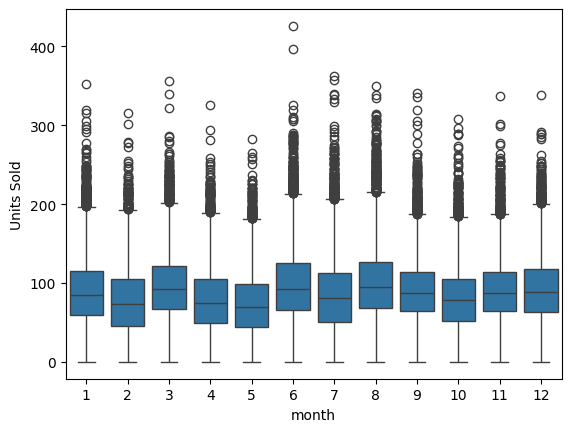

In [28]:
sns.boxplot(x='month', y='Units Sold', data=df) # Seasonality

Seasonal demand

High performing products

Store performance

Promotion impact

Demand Forecasting

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

features = df[['Price','Discount','month']]
target = df['Units Sold']

X_train, X_test, y_train, y_test = train_test_split(features,target,test_size=0.2)

model = LinearRegression()
model.fit(X_train,y_train)

predictions = model.predict(X_test)

In [32]:
predictions

array([ 81.72194904,  79.4844776 , 104.86140744, ...,  95.24244749,
        86.74552308,  96.96333771], shape=(15200,))

Inventory Optimization

Safety Stock=Z×σd​×L
​

In [35]:
demand_std = df['Units Sold'].std()
lead_time = 7

safety_stock = 1.65 * demand_std * np.sqrt(lead_time)

safety_stock

np.float64(192.05764395275472)

Reorder Point

In [38]:
avg_demand = df['Units Sold'].mean()

reorder_point = (avg_demand * lead_time) + safety_stock
reorder_point

np.float64(813.8488544790705)

In [39]:
D = df['Units Sold'].sum()
S = 50
H = 2

EOQ = np.sqrt((2*D*S)/H)


In [40]:
EOQ

np.float64(18372.365117207963)

In [41]:
df.to_csv("inventory_analysis_output.csv",index=False)